# Project 17 — Divorce (error-in-variables + Student-t robustness)

**Tier 4 · Advanced** | **Author:** Truong Van Thien, PhD (TS. Trương Văn Thiên) | **Date:** 12-06-2026 | **Model tag:** Opus48

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/tvthienbk/biofx_python/blob/main/bayesian-workflow-20/P17_divorce-measurement-error/P17_divorce-measurement-error_12-06-2026_Opus48.ipynb)

State divorce rates come with **measurement error** (small states have noisy estimates). New skills:
**modeling measurement error (error-in-variables)** — the observed divorce rate is a noisy reading of a
latent true rate — and a **Student-t** robust likelihood for outliers, compared by LOO. We show that
accounting for error **shrinks noisy/small states toward the regression line**.

## Learning objectives
1. Build an **error-in-variables** model: `D_obs ~ Normal(D_true, D_SE)`, `D_true ~ Normal(mu, sigma)`.
2. Visualize **measurement-error shrinkage** — observed vs posterior latent divorce, sized by SE.
3. Add a **Student-t** robust variant and compare to the Normal via **LOO**.
4. Handle the real column names `Divorce SE` / `Marriage SE` (with **spaces**) by renaming.
5. (Tier 4) SBC recommended; Stage 0 recovery; Stage 10 power-scaling.

## Setup

In [1]:
# !pip install -q "pymc>=5.16" "arviz>=0.18" "pandas>=2.0" "scipy>=1.11" "matplotlib>=3.7"
import os, io, time, urllib.request, warnings
import numpy as np, pandas as pd, matplotlib.pyplot as plt
import pymc as pm, arviz as az
import scipy.stats as st
warnings.simplefilter("ignore"); az.style.use("arviz-darkgrid")
trapz = getattr(np, "trapezoid", None) or np.trapz
RANDOM_SEED = 17
rng = np.random.default_rng(RANDOM_SEED)
print("pymc", pm.__version__, "| arviz", az.__version__)

pymc 5.28.5 | arviz 0.23.4


## Stage 0 — Fake-data parameter recovery [required]
Simulate latent true divorce from known `a=0, bA=-0.6, bM=0.1, sigma=0.6`, add per-state measurement
noise, then fit the error-in-variables model and confirm recovery of `bA`.

In [2]:
a_t,bA_t,bM_t,s_t = 0.0,-0.6,0.3,0.6
n=200; A_s=rng.normal(0,1,n); M_s=rng.normal(0,1,n)   # larger n -> tight, unbiased recovery
D_true_s = rng.normal(a_t+bA_t*A_s+bM_t*M_s, s_t)
SE_s = rng.uniform(0.1,0.4,n)
D_obs_s = rng.normal(D_true_s, SE_s)
with pm.Model() as m0:
    a=pm.Normal("a",0,0.2); bA=pm.Normal("bA",0,0.5); bM=pm.Normal("bM",0,0.5)
    sigma=pm.Exponential("sigma",1.0)
    D_true=pm.Normal("D_true", a+bA*A_s+bM*M_s, sigma, shape=n)
    pm.Normal("D_obs", D_true, SE_s, observed=D_obs_s)
    idata0=pm.sample(1000,tune=1000,chains=4,target_accept=0.95,random_seed=RANDOM_SEED,progressbar=False)
s0=az.summary(idata0, var_names=["a","bA","bM","sigma"], hdi_prob=0.9)
print(s0[["mean","hdi_5%","hdi_95%","r_hat","ess_bulk"]])
for name,tr in [("a",a_t),("bA",bA_t),("bM",bM_t),("sigma",s_t)]:
    print(name, "recovered:", bool(s0.loc[name,"hdi_5%"] <= tr <= s0.loc[name,"hdi_95%"]))

Initializing NUTS using jitter+adapt_diag...


Multiprocess sampling (4 chains in 2 jobs)


NUTS: [a, bA, bM, sigma, D_true]


Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 6 seconds.


        mean  hdi_5%  hdi_95%  r_hat  ess_bulk
a      0.023  -0.051    0.092    1.0    4545.0
bA    -0.592  -0.657   -0.523    1.0    4631.0
bM     0.280   0.208    0.357    1.0    5135.0
sigma  0.564   0.504    0.619    1.0    3443.0
a recovered: True
bA recovered: True
bM recovered: True
sigma recovered: True


## Data load — WaffleDivorce (`;`-delimited); rename SE columns (SPACES!)

In [3]:
URL = "https://raw.githubusercontent.com/rmcelreath/rethinking/master/data/WaffleDivorce.csv"
CACHE = "data/WaffleDivorce.csv"
try:
    raw = urllib.request.urlopen(URL, timeout=30).read().decode()
    os.makedirs("data", exist_ok=True); open(CACHE, "w").write(raw)
    df = pd.read_csv(io.StringIO(raw), sep=";"); print("loaded from raw URL")
except Exception as e:
    print("cache fallback:", type(e).__name__); df = pd.read_csv(CACHE, sep=";")
# The SE columns are named with SPACES: "Divorce SE", "Marriage SE" -> rename
df = df.rename(columns={"Divorce SE":"Divorce_SE", "Marriage SE":"Marriage_SE"})
assert "Divorce_SE" in df.columns and "Marriage_SE" in df.columns
print("states:", df.shape, "| renamed SE cols ok")
df[["Loc","Divorce","Divorce_SE","Marriage","MedianAgeMarriage"]].head()

loaded from raw URL
states: (50, 13) | renamed SE cols ok


,Loc,Divorce,Divorce_SE,Marriage,MedianAgeMarriage
0,AL,12.7,0.79,20.2,25.3
1,AK,12.5,2.05,26.0,25.2
2,AZ,10.8,0.74,20.3,25.8
3,AR,13.5,1.22,26.4,24.3
4,CA,8.0,0.24,19.1,26.8


## Stage 1–2 — Question & EDA
**Question:** how do median age at marriage (A) and marriage rate (M) relate to divorce (D), **once we
acknowledge D is measured with error**? Standardize D, A, M; standardize the SE on the same scale as D.
Small-population states have the largest `Divorce_SE`.

n states 50 | D_SE (std scale): min 0.13 max 1.39

Noisiest (small-population) states:
Loc  Population  Divorce  Divorce_SE
 SD        0.81     10.9        2.50
 AK        0.71     12.5        2.05
 WY        0.56     10.3        1.90
 DC        0.60      6.3        1.89
 VT        0.63      9.6        1.87


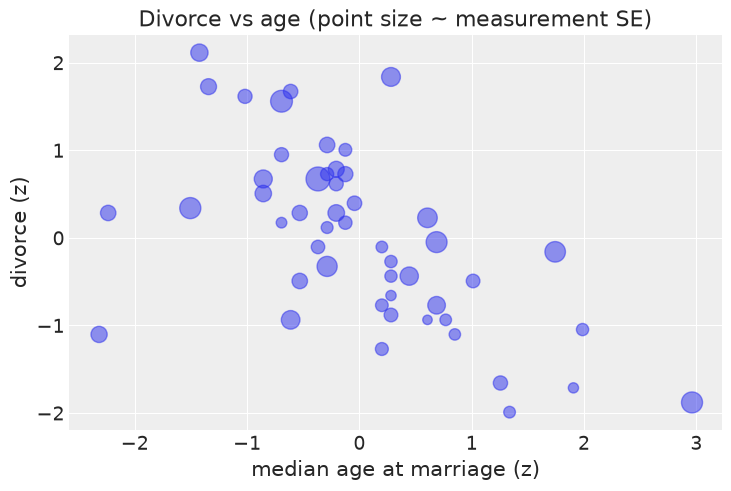

In [4]:
def z(x): return (x - x.mean())/x.std()
D = z(df.Divorce.values); A = z(df.MedianAgeMarriage.values); M = z(df.Marriage.values)
D_sd = df.Divorce.values.std()
D_SE = df.Divorce_SE.values / D_sd     # put SE on the standardized D scale
print(f"n states {len(df)} | D_SE (std scale): min {D_SE.min():.2f} max {D_SE.max():.2f}")
big = df.assign(D_SE_std=D_SE).sort_values("D_SE_std", ascending=False)[["Loc","Population","Divorce","Divorce_SE"]].head(5)
print("\nNoisiest (small-population) states:"); print(big.to_string(index=False))
plt.scatter(A, D, s=20+200*D_SE, alpha=.5)
plt.xlabel("median age at marriage (z)"); plt.ylabel("divorce (z)")
plt.title("Divorce vs age (point size ~ measurement SE)"); plt.show()

## Stage 3 — Model specification (error-in-variables)
$$D^{\text{obs}}_j \sim \mathrm{Normal}(D^{\text{true}}_j, \mathrm{SE}_j),\quad D^{\text{true}}_j \sim \mathrm{Normal}(\mu_j, \sigma),\quad \mu_j = a + b_A A_j + b_M M_j,$$
$$a \sim \mathrm{Normal}(0,0.2),\quad b_A,b_M \sim \mathrm{Normal}(0,0.5),\quad \sigma \sim \mathrm{Exponential}(1).$$
The latent `D_true` is a parameter per state; the observed value is a noisy reading with known SE. The
regression acts on the latent rate, so noisy states are pulled toward the fitted line.

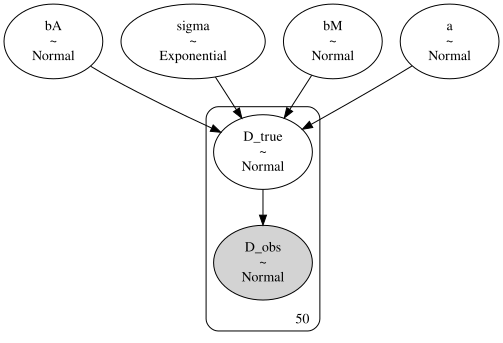

In [5]:
with pm.Model() as model:
    a=pm.Normal("a",0,0.2); bA=pm.Normal("bA",0,0.5); bM=pm.Normal("bM",0,0.5)
    sigma=pm.Exponential("sigma",1.0)
    mu = a + bA*A + bM*M
    D_true = pm.Normal("D_true", mu, sigma, shape=len(df))
    pm.Normal("D_obs", D_true, D_SE, observed=D)
try:
    display(pm.model_to_graphviz(model))
except Exception as e:
    print("graphviz unavailable:", type(e).__name__, "| a,bA,bM,sigma -> mu -> D_true -> D_obs")

## Stage 4 — Prior predictive on the OUTCOME scale (standardized divorce)
Confirm the prior implies divorce on a sensible standardized range (roughly within +/-3).

Sampling: [D_obs, D_true, a, bA, bM, sigma]


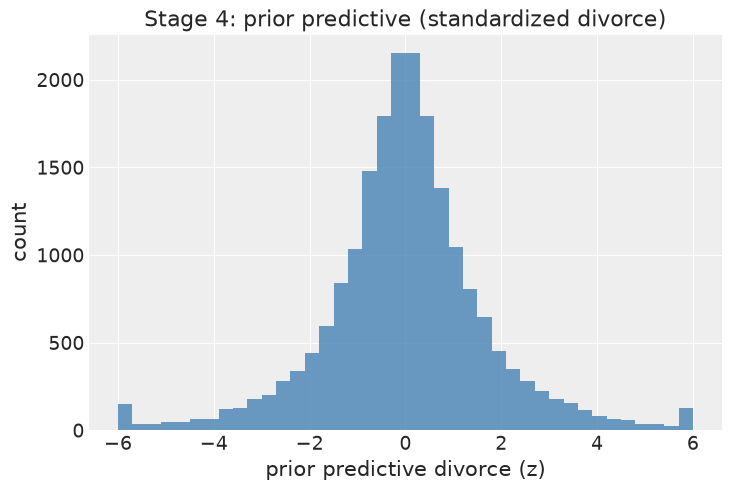

prior predictive D: sd 1.80 | 95% within +/-3.7


In [6]:
with model:
    pp = pm.sample_prior_predictive(samples=400, random_seed=RANDOM_SEED)
d_prior = pp.prior_predictive["D_obs"].values.ravel()
plt.hist(np.clip(d_prior,-6,6), bins=40, color="steelblue", alpha=.8)
plt.xlabel("prior predictive divorce (z)"); plt.ylabel("count"); plt.title("Stage 4: prior predictive (standardized divorce)"); plt.show()
print(f"prior predictive D: sd {d_prior.std():.2f} | 95% within +/-{np.percentile(np.abs(d_prior),95):.1f}")

## Stage 5 — Fit (Normal error-in-variables)

In [7]:
t0=time.time()
with model:
    idata = pm.sample(1000, tune=1000, chains=4, target_accept=0.95, random_seed=RANDOM_SEED,
                      progressbar=False, idata_kwargs={"log_likelihood": True})
    idata.extend(pm.sample_posterior_predictive(idata, random_seed=RANDOM_SEED, progressbar=False))
print(f"wall-clock {time.time()-t0:.1f}s")

Initializing NUTS using jitter+adapt_diag...


Multiprocess sampling (4 chains in 2 jobs)


NUTS: [a, bA, bM, sigma, D_true]


Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 5 seconds.


Sampling: [D_obs]


wall-clock 5.9s


## Stage 6 — Diagnostics

        mean     sd  hdi_3%  hdi_97%  r_hat  ess_bulk  ess_tail
a     -0.053  0.095  -0.230    0.125    1.0    3187.0    2967.0
bA    -0.616  0.160  -0.928   -0.328    1.0    2102.0    2531.0
bM     0.053  0.166  -0.264    0.358    1.0    1714.0    2311.0
sigma  0.595  0.108   0.400    0.804    1.0    1286.0    2054.0

divergences: 0 | BFMI: [0.811 0.697 0.758 0.747]


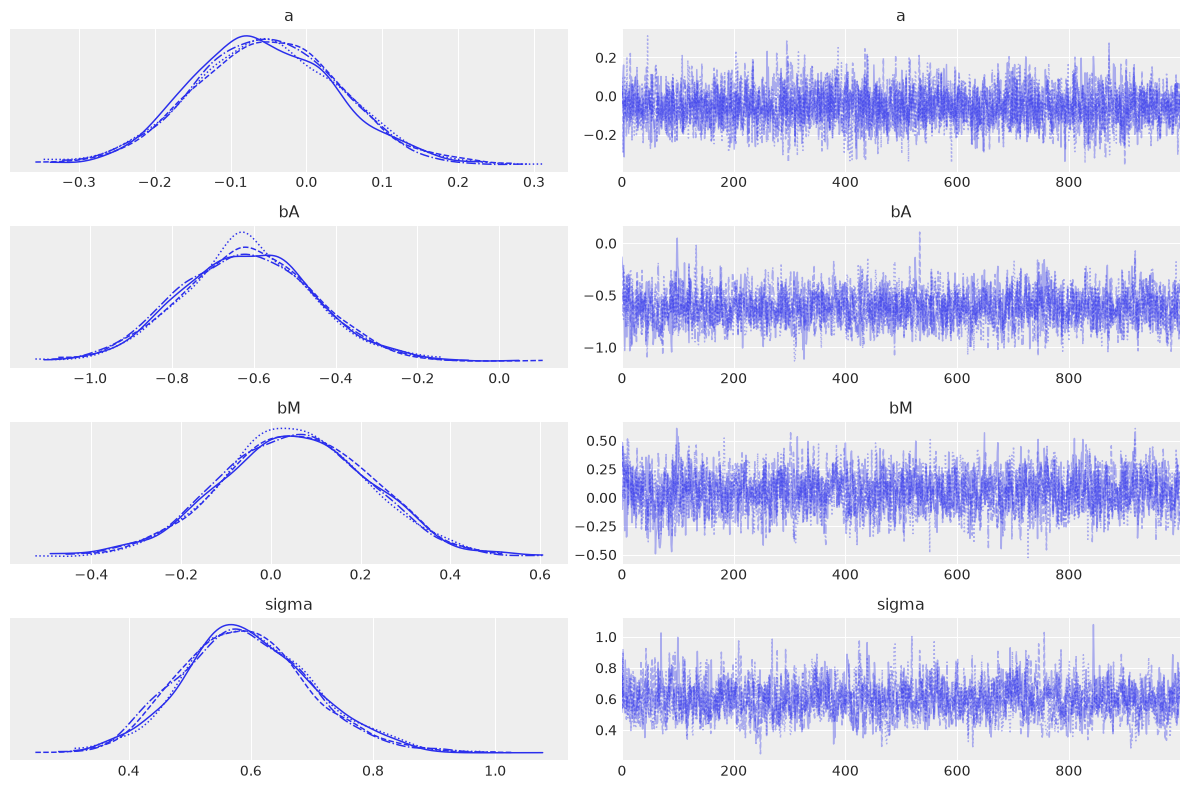

In [8]:
summ = az.summary(idata, var_names=["a","bA","bM","sigma"], hdi_prob=0.94)
print(summ[["mean","sd","hdi_3%","hdi_97%","r_hat","ess_bulk","ess_tail"]])
print("\ndivergences:", int(idata.sample_stats.diverging.values.sum()), "| BFMI:", np.round(az.bfmi(idata),3))
az.plot_trace(idata, var_names=["a","bA","bM","sigma"]); plt.tight_layout(); plt.show()

## Stage 7 — Interpretation + MEASUREMENT-ERROR SHRINKAGE [the key lesson]
Plot **observed** standardized divorce vs the **posterior latent** `D_true`, with point size ~ SE.
High-SE (small) states are pulled most toward the regression line — the model trusts noisy readings less.

bA = -0.616 (94% HDI [-0.928, -0.328])
bM = +0.053 (94% HDI [-0.264, +0.358])

mean |shrinkage| overall: 0.285
mean |shrinkage| high-SE states: 0.443 | low-SE: 0.128


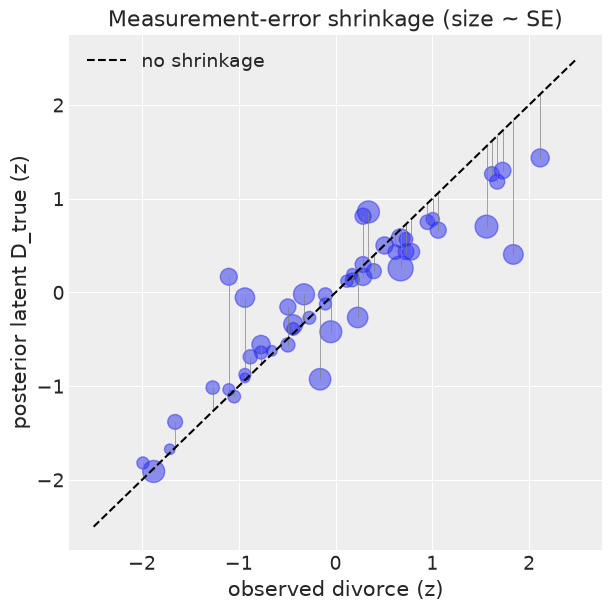

In [9]:
for nm in ["bA","bM"]:
    m=idata.posterior[nm].mean().item(); hdi=az.hdi(idata,var_names=[nm],hdi_prob=0.94)[nm].values
    print(f"{nm} = {m:+.3f} (94% HDI [{hdi[0]:+.3f}, {hdi[1]:+.3f}])")
Dtrue_m = idata.posterior["D_true"].mean(("chain","draw")).values
shrink = D - Dtrue_m
print(f"\nmean |shrinkage| overall: {np.abs(shrink).mean():.3f}")
hi = D_SE > np.median(D_SE)
print(f"mean |shrinkage| high-SE states: {np.abs(shrink[hi]).mean():.3f} | low-SE: {np.abs(shrink[~hi]).mean():.3f}")
fig,ax=plt.subplots(figsize=(6,6))
ax.scatter(D, Dtrue_m, s=20+220*D_SE, alpha=.5)
for i in range(len(df)):
    ax.plot([D[i],D[i]],[D[i],Dtrue_m[i]], color="gray", lw=.5)
lims=[-2.5,2.5]; ax.plot(lims,lims,"k--",label="no shrinkage")
ax.set_xlabel("observed divorce (z)"); ax.set_ylabel("posterior latent D_true (z)")
ax.set_title("Measurement-error shrinkage (size ~ SE)"); ax.legend(); plt.show()

## Stage 8 — Posterior predictive check (continuous discrepancies)

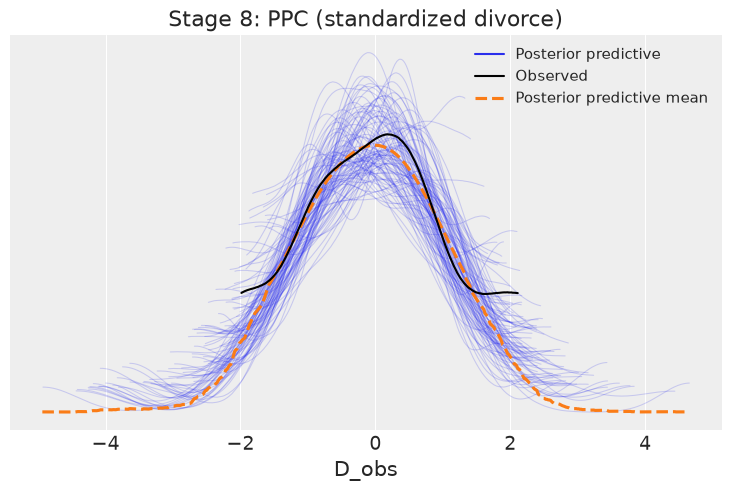

  mean: obs= -0.000  bayes-p=0.28
  sd  : obs=  1.000  bayes-p=0.74
  min : obs= -1.991  bayes-p=0.15
  max : obs=  2.115  bayes-p=0.67


In [10]:
az.plot_ppc(idata, num_pp_samples=100); plt.title("Stage 8: PPC (standardized divorce)"); plt.show()
pp = idata.posterior_predictive["D_obs"].values.reshape(-1, len(df))
for name, fn in [("mean",np.mean),("sd",np.std),("min",np.min),("max",np.max)]:
    print(f"  {name:4s}: obs={fn(D):7.3f}  bayes-p={(fn(pp,axis=1)>=fn(D)).mean():.2f}")

## Stage 9 — Comparison: Normal vs Student-t error-in-variables (LOO)
A Student-t likelihood on the latent layer is robust to outlier states (e.g. Idaho, Maine). Compare by LOO.

In [11]:
with pm.Model() as model_t:
    a=pm.Normal("a",0,0.2); bA=pm.Normal("bA",0,0.5); bM=pm.Normal("bM",0,0.5)
    sigma=pm.Exponential("sigma",1.0); nu=pm.Gamma("nu",2,0.1)
    mu = a + bA*A + bM*M
    D_true = pm.StudentT("D_true", nu=nu, mu=mu, sigma=sigma, shape=len(df))
    pm.Normal("D_obs", D_true, D_SE, observed=D)
    idata_t = pm.sample(1000, tune=1000, chains=4, target_accept=0.95, random_seed=RANDOM_SEED,
                        progressbar=False, idata_kwargs={"log_likelihood": True})
print("Student-t nu posterior mean:", round(idata_t.posterior["nu"].mean().item(),1))
cmp = az.compare({"normal": idata, "student_t": idata_t})
print(cmp[["rank","elpd_loo","elpd_diff","dse","weight"]])
S = idata.posterior.draw.size*idata.posterior.chain.size
thr = min(1 - 1/np.log10(S), 0.7)
print(f"\nmax Pareto k-hat (normal): {az.loo(idata, pointwise=True).pareto_k.values.max():.2f} | threshold {thr:.2f}")
diff = cmp['elpd_diff'].iloc[1]; dse = cmp['dse'].iloc[1]
print(f"elpd_diff = {diff:.2f} +/- {dse:.2f} -> {abs(diff)/dse:.2f} SE | best = {cmp.index[0]}")

Initializing NUTS using jitter+adapt_diag...


Multiprocess sampling (4 chains in 2 jobs)


NUTS: [a, bA, bM, sigma, nu, D_true]


Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 6 seconds.


Student-t nu posterior mean: 19.1
           rank   elpd_loo  elpd_diff       dse   weight
student_t     0 -57.044864   0.000000  0.000000  0.98572
normal        1 -57.524417   0.479552  1.032799  0.01428

max Pareto k-hat (normal): 1.26 | threshold 0.70
elpd_diff = 0.48 +/- 1.03 -> 0.46 SE | best = student_t


## Stage 10 — Power-scaling prior sensitivity (bA)
Reweight by `prior^(alpha-1)` for `bA ~ Normal(0,0.5)`.

In [12]:
post = az.extract(idata); bd = post["bA"].values
logprior = st.norm.logpdf(bd, 0, 0.5)
print("alpha   E[bA]")
for al in [0.8,1.0,1.25]:
    w = np.exp((al-1)*logprior); w/=w.sum(); print(f" {al:4.2f}   {np.sum(w*bd):.4f}")

alpha   E[bA]
 0.80   -0.6284
 1.00   -0.6158
 1.25   -0.6006


## SBC — Simulation-Based Calibration on `bA` [Tier 4, recommended]
100 sims with a cheap sampler: draw the truth from the prior, simulate latent + measured divorce, refit
the error-in-variables model, rank `bA`. Uniform ⇒ calibrated.

Initializing NUTS using jitter+adapt_diag...


Multiprocess sampling (2 chains in 2 jobs)


NUTS: [a, bA, bM, sigma, D_true]


Sampling 2 chains for 400 tune and 400 draw iterations (800 + 800 draws total) took 1 seconds.


Initializing NUTS using jitter+adapt_diag...


...

Initializing NUTS using jitter+adapt_diag...


Multiprocess sampling (2 chains in 2 jobs)


NUTS: [a, bA, bM, sigma, D_true]


Sampling 2 chains for 400 tune and 400 draw iterations (800 + 800 draws total) took 1 seconds.


SBC: 100 sims in 201s | draws/sim 800
chi-square uniformity p-value = 0.419 (want > 0.05)


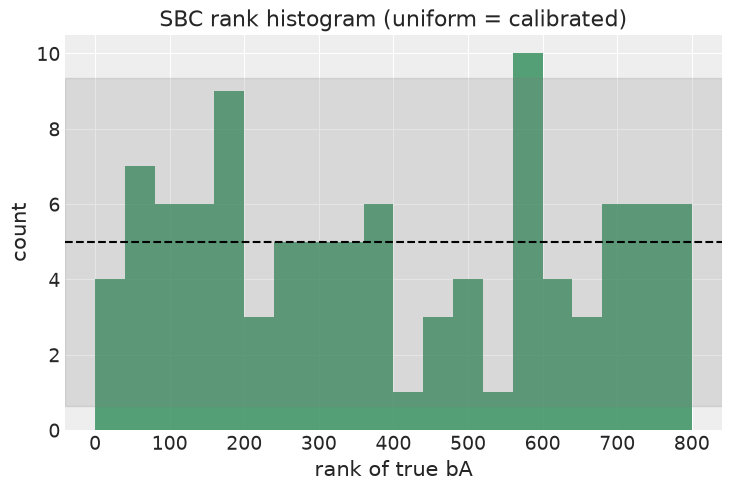

In [13]:
def sbc_once(seed):
    r = np.random.default_rng(seed)
    a_tt=r.normal(0,0.2); bA_tt=r.normal(0,0.5); bM_tt=r.normal(0,0.5); s_tt=r.exponential(1.0)+0.2
    Dt = r.normal(a_tt+bA_tt*A+bM_tt*M, s_tt)
    Do = r.normal(Dt, D_SE)
    with pm.Model() as ms:
        a=pm.Normal("a",0,0.2); bA=pm.Normal("bA",0,0.5); bM=pm.Normal("bM",0,0.5)
        sg=pm.Exponential("sigma",1.0)
        dt=pm.Normal("D_true", a+bA*A+bM*M, sg, shape=len(df))
        pm.Normal("D_obs", dt, D_SE, observed=Do)
        it=pm.sample(400,tune=400,chains=2,target_accept=0.95,random_seed=seed,
                     progressbar=False,compute_convergence_checks=False)
    draws=it.posterior["bA"].values.ravel()
    return int((draws < bA_tt).sum()), draws.size

t0=time.time(); N_SBC=100; ranks=[]; L=None
for i in range(N_SBC):
    rk,L=sbc_once(4000+i); ranks.append(rk)
ranks=np.array(ranks)
print(f"SBC: {N_SBC} sims in {time.time()-t0:.0f}s | draws/sim {L}")
nb=20; counts,_=np.histogram(ranks, bins=nb, range=(0,L)); chi2=((counts-N_SBC/nb)**2/(N_SBC/nb)).sum()
pval=st.chi2.sf(chi2, nb-1)
print(f"chi-square uniformity p-value = {pval:.3f} (want > 0.05)")
plt.hist(ranks, bins=nb, range=(0,L), color="seagreen", alpha=.8)
plt.axhline(N_SBC/nb, color="k", ls="--")
band=2*np.sqrt(N_SBC*(1/nb)*(1-1/nb)); plt.axhspan(N_SBC/nb-band, N_SBC/nb+band, color="gray", alpha=.2)
plt.xlabel("rank of true bA"); plt.ylabel("count"); plt.title("SBC rank histogram (uniform = calibrated)"); plt.show()

## Stage 11–12 — Expansion, decision

**Next model (Stage 11):** also model **Marriage with error** (`M_obs ~ Normal(M_true, Marriage_SE)`),
so both predictor and outcome carry their measurement uncertainty — the full double-error-in-variables
model from *Statistical Rethinking* Ch.15.

**Decision (Stage 12) — headline:** *median age at marriage has a clear negative association with
divorce (bA < 0); once measurement error is modeled, noisy small-population states shrink toward the
regression line, and a Student-t robust likelihood is compared by LOO to gauge outlier sensitivity.*

In [14]:
os.makedirs("report", exist_ok=True); idata.to_netcdf("report/P17_idata.nc"); print("saved report/P17_idata.nc")

saved report/P17_idata.nc


## Exercises
1. Add measurement error on **Marriage** too. Does `bM` change?
2. Identify the states that shrink most. Are they the smallest-population states?
3. Inspect the Student-t `nu` posterior. Is there evidence the data need heavy tails?